# Actual Analysis of Research Survey Dataset

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer

In [2]:
INPUT_FILE = "../dataset/wm_planning_analytics_complete_archive_0717/master/wm_planning_analytics_master.csv"
df = pd.read_csv(
    INPUT_FILE
)
df.columns.to_frame(index=False, name="Column")

,Column
0,batch_id
1,paper_id
2,title
3,authors
4,year
5,year_basis
6,venue
7,publication_status
8,paper_type
9,citation_count


## Load and clean dataset

In [3]:
# All generated figures will be saved here.
OUTPUT_DIR = Path("../figs/analytical_plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Methods-only is generally better for architecture and planning analysis.
# Change this to False to include surveys, benchmarks, and dataset papers.
METHODS_ONLY = True

TOP_N = 15
FIGURE_DPI = 200

In [4]:
# Normalize column names.
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

# Handle alternate spellings and typos.
COLUMN_ALIASES = {
    "uses_wm": "uses_world_model",
    "wm_family": "world_model_family",
    "human_robot_collaboration": "human_robot_interaction",
    "goa_representation": "goal_representation",
    "goal_represenation": "goal_representation",
    "heirarchical_planning": "hierarchical_planning",
}

df = df.rename(
    columns={
        old_name: new_name
        for old_name, new_name in COLUMN_ALIASES.items()
        if old_name in df.columns
    }
)

# Strip whitespace from text columns and replace empty strings with NaN
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip()
    df[column] = df[column].replace("", np.nan)

if METHODS_ONLY:
    analysis_df = df[df["paper_type"].eq("Method")].copy()
else:
    analysis_df = df.copy()

print(f"Full dataset: {len(df)} papers")
print(f"Analysis dataset: {len(analysis_df)} papers")
print(f"Methods only: {METHODS_ONLY}")

Full dataset: 68 papers
Analysis dataset: 47 papers
Methods only: True


/tmp/ipykernel_6563/3596002522.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df.select_dtypes(include="object").columns:


## Plot and normalization functions

In [5]:
def safe_filename(text):
    """Create 'safe' file names."""
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


def save_and_show(fig, section, name):
    """Save and display figs"""
    section_dir = OUTPUT_DIR / section
    section_dir.mkdir(parents=True, exist_ok=True)

    output_path = section_dir / f"{safe_filename(name)}.png"

    fig.tight_layout()
    fig.savefig(
        output_path,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

    print(f"Saved: {output_path}")


def normalize_status(value):
    """
    Reduce qualified Yes/No fields into a smaller set of categories.

    Examples:
        'Yes — action chunks are regenerated' -> 'Yes'
        'No / Unclear' -> 'No / Unclear'
        'Both / Survey' -> 'Both / Survey'
    """
    if pd.isna(value):
        return "Missing"

    value = str(value).strip()
    lower = value.lower()

    if lower in {"n/a", "na", "not applicable"}:
        return "N/A"

    if lower.startswith("no / unclear"):
        return "No / Unclear"

    if lower.startswith("yes"):
        return "Yes"

    if lower.startswith("no"):
        return "No"

    if lower.startswith("both"):
        return "Both / Survey"

    if lower.startswith("unknown"):
        return "Unknown"

    return "Qualified"


def split_multilabel(value):
    """
    Split semicolon or pipe-separated fields

    Commas are deliberately not used as separators because many cells
    contain descriptive phrases with commas
    """
    if pd.isna(value):
        return []

    values = re.split(r"\s*[;|]\s*", str(value))

    cleaned = []
    for item in values:
        item = item.strip()

        if not item:
            continue

        if item.lower() in {"n/a", "na", "none", "unknown"}:
            continue

        cleaned.append(item)

    return cleaned

## Categorical Plot

In [6]:
def plot_category_counts(
    data,
    column,
    title=None,
    section="misc",
    order=None,
    transform=None,
):
    """Plot counts for a single categorical column"""
    if column not in data.columns:
        print(f"Skipping missing column: {column}")
        return

    series = data[column].copy()

    if transform is not None:
        series = series.map(transform)

    series = series.fillna("Missing")
    counts = series.value_counts()

    if order is not None:
        remaining = [value for value in counts.index if value not in order]
        counts = counts.reindex(order + remaining).dropna()

    # Reverse for horizontal plotting so the largest/first appears on top.
    counts = counts.iloc[::-1]

    fig, ax = plt.subplots(
        figsize=(9, max(4, 0.45 * len(counts)))
    )

    ax.barh(counts.index, counts.values)
    ax.set_xlabel("Number of papers")
    ax.set_ylabel("")
    ax.set_title(title or column.replace("_", " ").title())

    maximum = counts.max() if len(counts) else 1

    for index, value in enumerate(counts.values):
        ax.text(
            value + maximum * 0.01,
            index,
            str(int(value)),
            va="center",
        )

    save_and_show(
        fig,
        section,
        title or column,
    )

## Multi-label Plot

In [7]:
def get_multilabel_counts(data, column):
    """Count semicolon-separated labels in a column."""
    if column not in data.columns:
        return pd.Series(dtype=int)

    exploded = (
        data[column]
        .dropna()
        .map(split_multilabel)
        .explode()
        .dropna()
    )

    return exploded.value_counts()


def plot_multilabel_counts(
    data,
    column,
    title=None,
    section="misc",
    top_n=TOP_N,
):
    """Plot the most common labels from a multi-label column."""
    counts = get_multilabel_counts(data, column).head(top_n)

    if counts.empty:
        print(f"No usable data for: {column}")
        return

    counts = counts.iloc[::-1]

    fig, ax = plt.subplots(
        figsize=(10, max(5, 0.5 * len(counts)))
    )

    ax.barh(counts.index, counts.values)
    ax.set_xlabel("Number of papers")
    ax.set_ylabel("")
    ax.set_title(title or column.replace("_", " ").title())

    maximum = counts.max()

    for index, value in enumerate(counts.values):
        ax.text(
            value + maximum * 0.01,
            index,
            str(int(value)),
            va="center",
        )

    save_and_show(
        fig,
        section,
        title or column,
    )

## Free-text term freq

In [8]:
TEXT_STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by",
    "for", "from", "in", "into", "is", "it", "of", "on",
    "or", "that", "the", "their", "through", "to", "using",
    "via", "with", "without",

    # Very common corpus terms that may hide more informative concepts.
    "model", "models", "robot", "robotic", "robots",
    "task", "tasks", "action", "actions", "state", "states",
    "multiple", "method", "methods", "system", "systems",
    "based", "specific", "n", "none",
}


def plot_text_terms(
    data,
    column,
    title=None,
    section="misc",
    top_n=TOP_N,
    ngram_range=(1, 2),
    min_document_frequency=2,
):
    """
    Plot common words and two-word phrases from high-cardinality
    descriptive fields such as planning_representation or horizon_basis.
    """
    if column not in data.columns:
        print(f"Skipping missing column: {column}")
        return

    text = (
        data[column]
        .dropna()
        .astype(str)
        .str.lower()
    )

    text = text[
        ~text.isin(
            ["n/a", "none", "unknown", "not applicable"]
        )
    ]

    if text.empty:
        print(f"No usable text for: {column}")
        return

    vectorizer = CountVectorizer(
        stop_words=list(TEXT_STOPWORDS),
        ngram_range=ngram_range,
        min_df=min_document_frequency,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z0-9\-]+\b",
    )

    try:
        matrix = vectorizer.fit_transform(text)
    except ValueError:
        print(f"Not enough repeated terms for: {column}")
        return

    frequencies = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()

    counts = (
        pd.Series(frequencies, index=terms)
        .sort_values(ascending=False)
        .head(top_n)
        .iloc[::-1]
    )

    fig, ax = plt.subplots(
        figsize=(10, max(5, 0.5 * len(counts)))
    )

    ax.barh(counts.index, counts.values)
    ax.set_xlabel("Number of term occurrences")
    ax.set_ylabel("")
    ax.set_title(title or f"Common Terms in {column}")

    maximum = counts.max()

    for index, value in enumerate(counts.values):
        ax.text(
            value + maximum * 0.01,
            index,
            str(int(value)),
            va="center",
        )

    save_and_show(
        fig,
        section,
        title or f"{column}_terms",
    )

## Heatmap for two-field relationships

In [9]:
def plot_relationship_heatmap(
    data,
    row_column,
    column_column,
    title,
    section,
    row_multilabel=False,
    column_multilabel=False,
    row_transform=None,
    column_transform=None,
    top_rows=12,
    top_columns=8,
):
    """
    Create a count heatmap between two categorical or multi-label fields
    """
    required = {row_column, column_column}

    if not required.issubset(data.columns):
        print(f"Skipping heatmap; missing: {required - set(data.columns)}")
        return

    pairs = []

    subset = data[[row_column, column_column]].dropna()

    for _, row in subset.iterrows():
        row_value = row[row_column]
        column_value = row[column_column]

        if row_multilabel:
            row_labels = split_multilabel(row_value)
        else:
            row_labels = [row_value]

        if column_multilabel:
            column_labels = split_multilabel(column_value)
        else:
            column_labels = [column_value]

        if row_transform is not None:
            row_labels = [row_transform(value) for value in row_labels]

        if column_transform is not None:
            column_labels = [
                column_transform(value)
                for value in column_labels
            ]

        for row_label in row_labels:
            for column_label in column_labels:
                if pd.isna(row_label) or pd.isna(column_label):
                    continue

                pairs.append(
                    {
                        "row": str(row_label),
                        "column": str(column_label),
                    }
                )

    if not pairs:
        print(f"No pairs found for {row_column} × {column_column}")
        return

    pair_df = pd.DataFrame(pairs)

    table = pd.crosstab(
        pair_df["row"],
        pair_df["column"],
    )

    top_row_labels = (
        table.sum(axis=1)
        .sort_values(ascending=False)
        .head(top_rows)
        .index
    )

    top_column_labels = (
        table.sum(axis=0)
        .sort_values(ascending=False)
        .head(top_columns)
        .index
    )

    table = table.loc[
        top_row_labels,
        top_column_labels,
    ]

    fig_width = max(8, len(table.columns) * 1.25)
    fig_height = max(5, len(table.index) * 0.55)

    fig, ax = plt.subplots(
        figsize=(fig_width, fig_height)
    )

    image = ax.imshow(
        table.values,
        aspect="auto",
    )

    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels(
        table.columns,
        rotation=45,
        ha="right",
    )

    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels(table.index)

    ax.set_xlabel(column_column.replace("_", " ").title())
    ax.set_ylabel(row_column.replace("_", " ").title())
    ax.set_title(title)

    fig.colorbar(
        image,
        ax=ax,
        label="Number of papers",
    )

    # Add count labels when the table is not too large.
    if table.shape[0] * table.shape[1] <= 120:
        for row_index in range(table.shape[0]):
            for column_index in range(table.shape[1]):
                value = table.iloc[row_index, column_index]

                if value > 0:
                    ax.text(
                        column_index,
                        row_index,
                        str(int(value)),
                        ha="center",
                        va="center",
                    )

    save_and_show(
        fig,
        section,
        title,
    )

# Section 1 analytics:
## Research focus and task characteristics

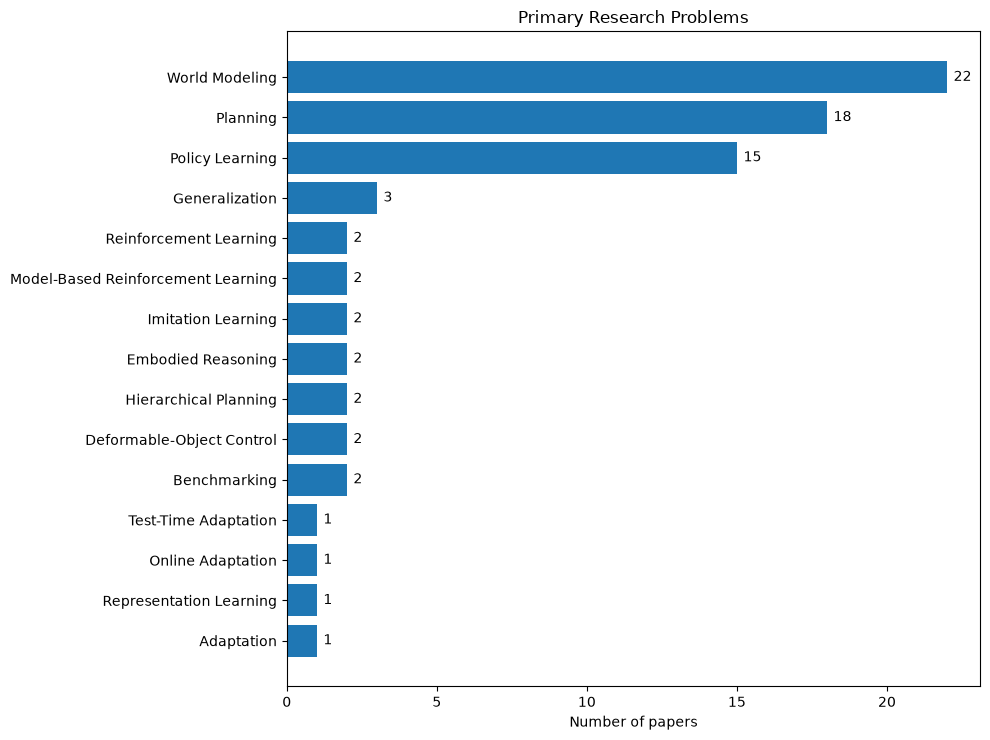

Saved: ../figs/analytical_plots/section_1_research_focus/primary_research_problems.png


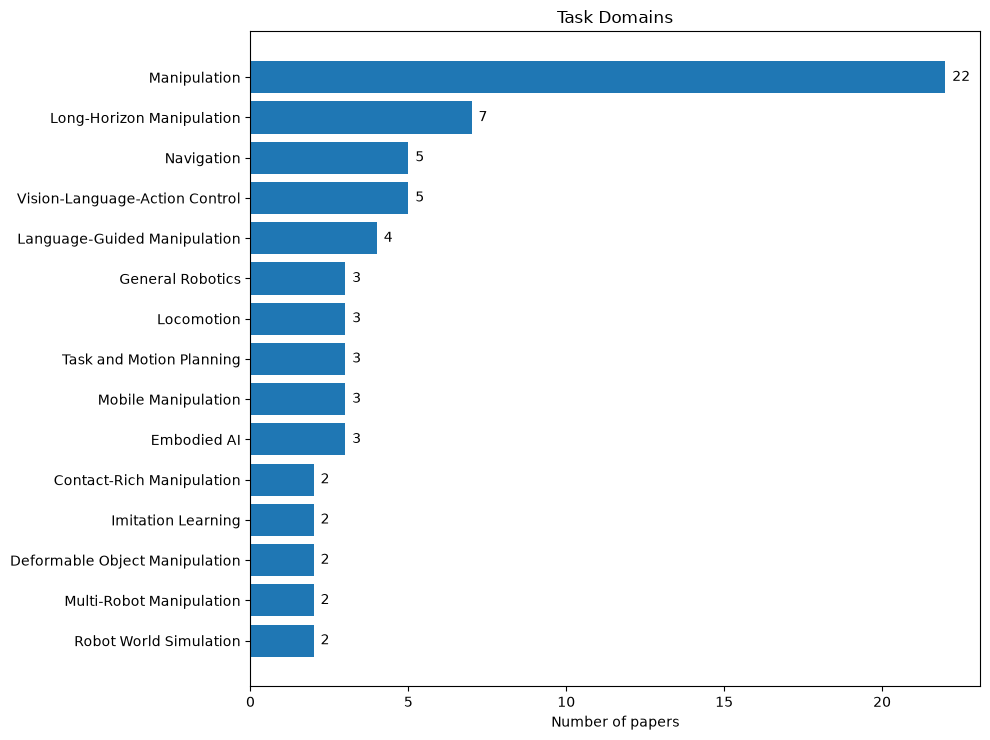

Saved: ../figs/analytical_plots/section_1_research_focus/task_domains.png


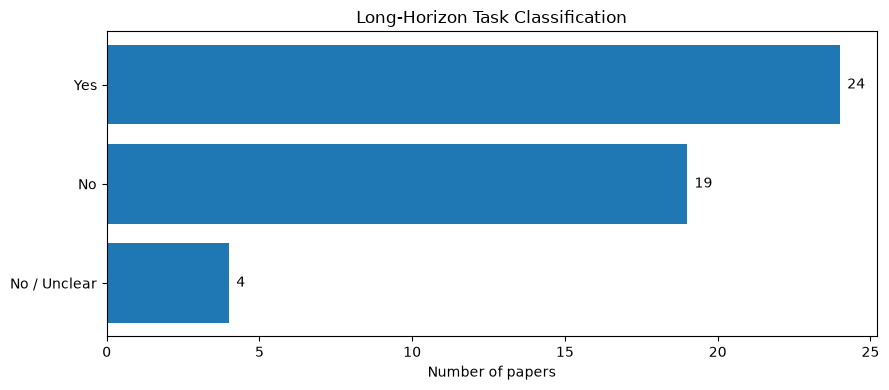

Saved: ../figs/analytical_plots/section_1_research_focus/long_horizon_task_classification.png


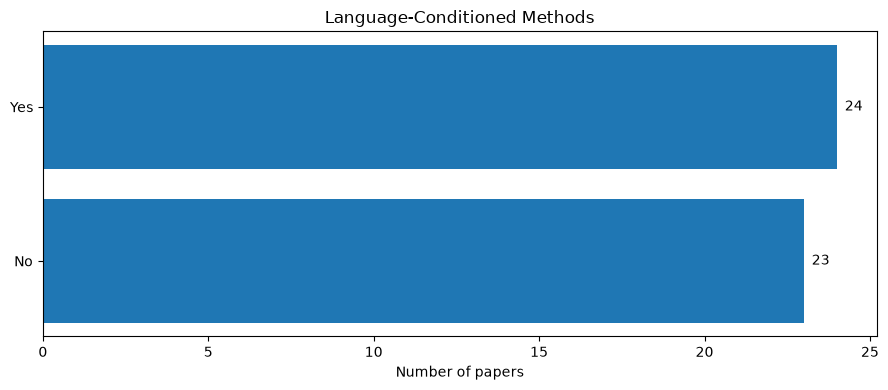

Saved: ../figs/analytical_plots/section_1_research_focus/language_conditioned_methods.png


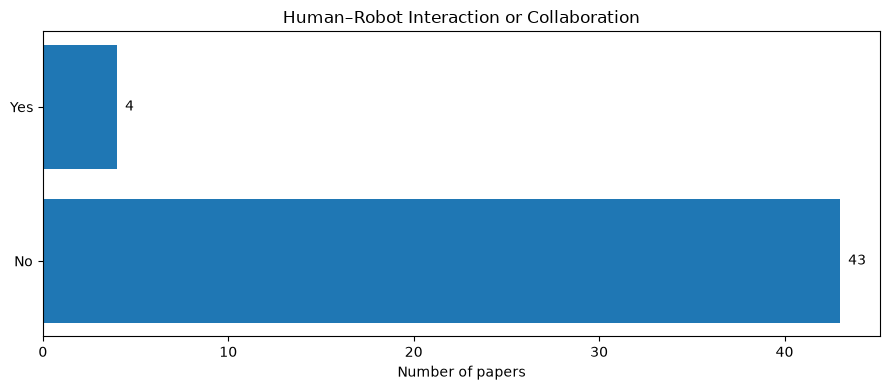

Saved: ../figs/analytical_plots/section_1_research_focus/human_robot_interaction_or_collaboration.png


In [10]:
SECTION = "section_1_research_focus"

plot_multilabel_counts(
    analysis_df,
    "primary_problem",
    title="Primary Research Problems",
    section=SECTION,
)

plot_multilabel_counts(
    analysis_df,
    "task_domain",
    title="Task Domains",
    section=SECTION,
)

plot_category_counts(
    analysis_df,
    "long_horizon",
    title="Long-Horizon Task Classification",
    section=SECTION,
    order=["Yes", "No", "No / Unclear", "N/A", "Missing"],
    transform=normalize_status,
)

plot_category_counts(
    analysis_df,
    "language_conditioned",
    title="Language-Conditioned Methods",
    section=SECTION,
    order=["Yes", "No", "No / Unclear", "N/A", "Missing"],
    transform=normalize_status,
)

plot_category_counts(
    analysis_df,
    "human_robot_interaction",
    title="Human–Robot Interaction or Collaboration",
    section=SECTION,
    order=["Yes", "No", "No / Unclear", "N/A", "Missing"],
    transform=normalize_status,
)

# Section 2: World Model Usage

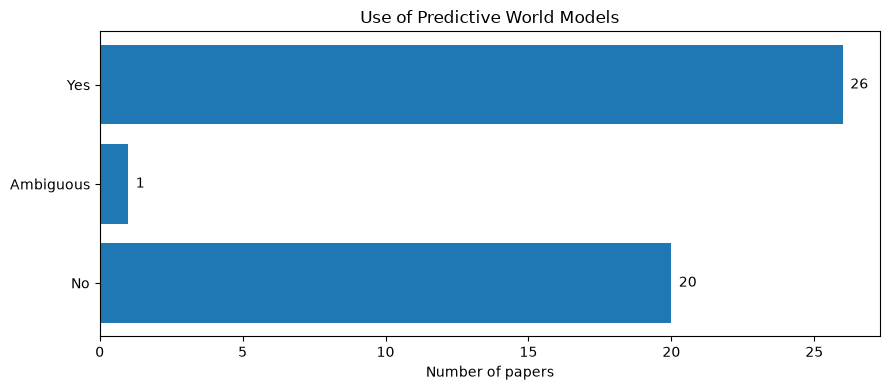

Saved: ../figs/analytical_plots/section_2_world_models/use_of_predictive_world_models.png


In [11]:
SECTION = "section_2_world_models"

plot_category_counts(
    analysis_df,
    "uses_world_model",
    title="Use of Predictive World Models",
    section=SECTION,
    order=["Yes", "Ambiguous", "No", "N/A", "Missing"],
)

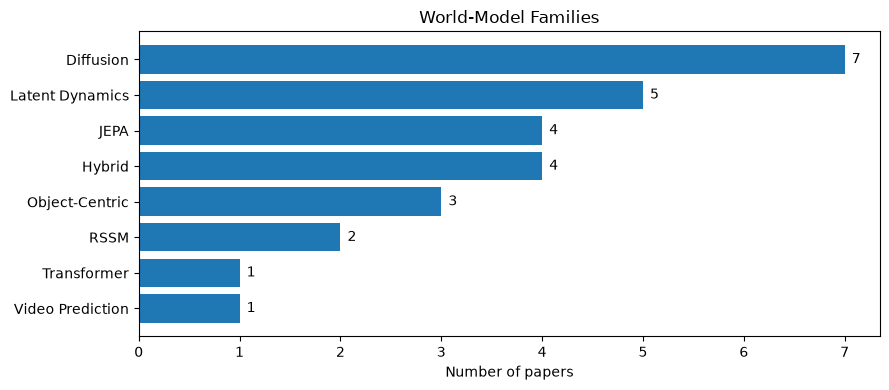

Saved: ../figs/analytical_plots/section_2_world_models/world_model_families.png


In [12]:
# Restrict family analysis to methods that actually use or claim a world model.
wm_df = analysis_df[
    analysis_df["uses_world_model"].isin(
        ["Yes", "Ambiguous"]
    )
].copy()

plot_category_counts(
    wm_df,
    "world_model_family",
    title="World-Model Families",
    section=SECTION,
)

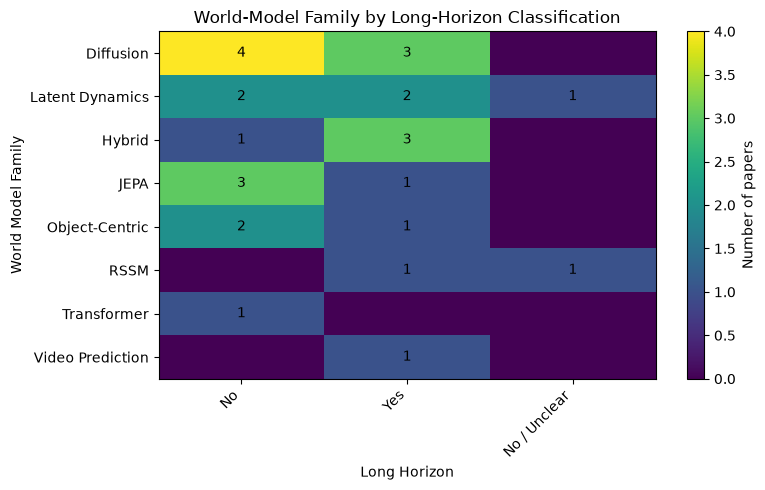

Saved: ../figs/analytical_plots/section_2_world_models/world_model_family_by_long_horizon_classification.png


In [13]:
plot_relationship_heatmap(
    wm_df,
    row_column="world_model_family",
    column_column="long_horizon",
    title="World-Model Family by Long-Horizon Classification",
    section=SECTION,
    column_transform=normalize_status,
)

# Section 3: Planning

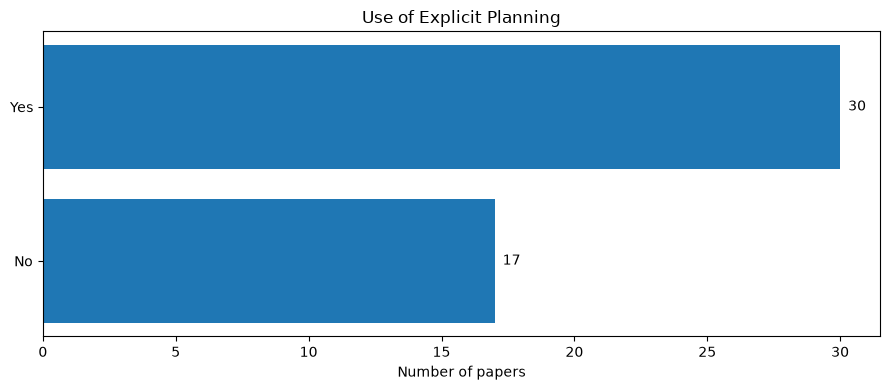

Saved: ../figs/analytical_plots/section_3_planning/use_of_explicit_planning.png


In [14]:
SECTION = "section_3_planning"

plot_category_counts(
    analysis_df,
    "uses_planning",
    title="Use of Explicit Planning",
    section=SECTION,
    order=["Yes", "No", "N/A", "Missing"],
)

In [15]:
planning_df = analysis_df[
    analysis_df["uses_planning"].eq("Yes")
].copy()

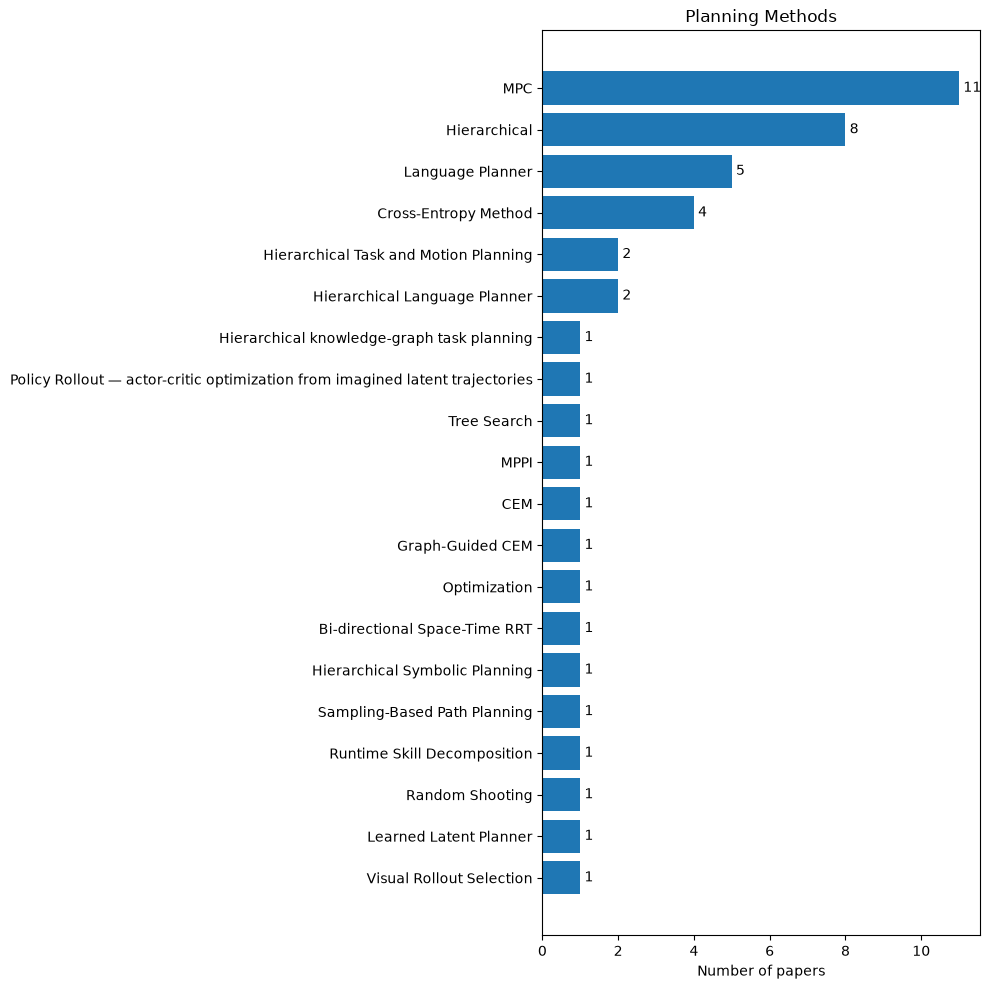

Saved: ../figs/analytical_plots/section_3_planning/planning_methods.png


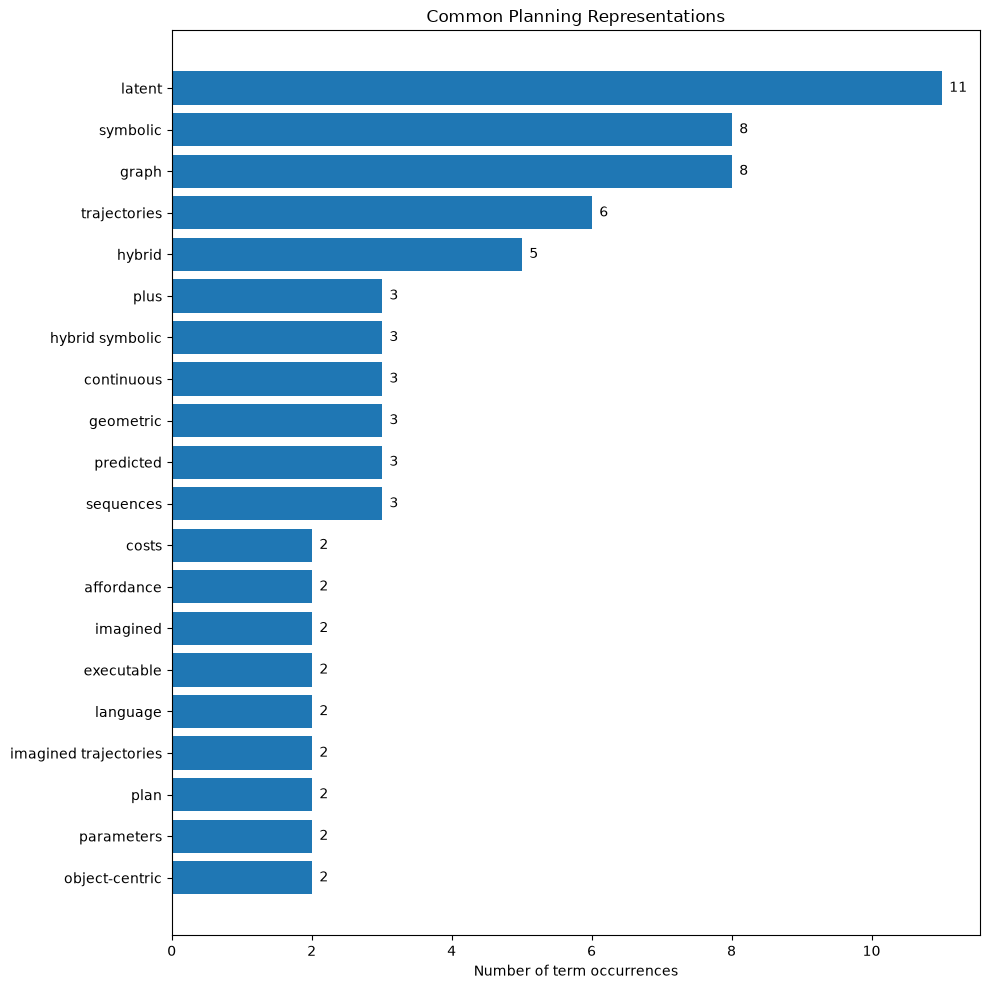

Saved: ../figs/analytical_plots/section_3_planning/common_planning_representations.png


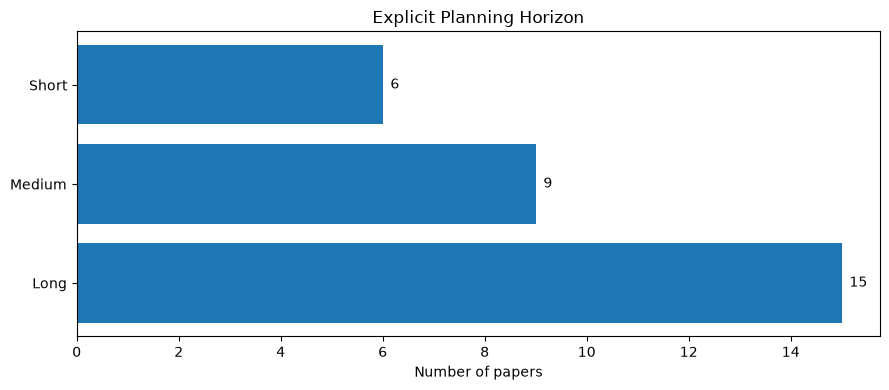

Saved: ../figs/analytical_plots/section_3_planning/explicit_planning_horizon.png


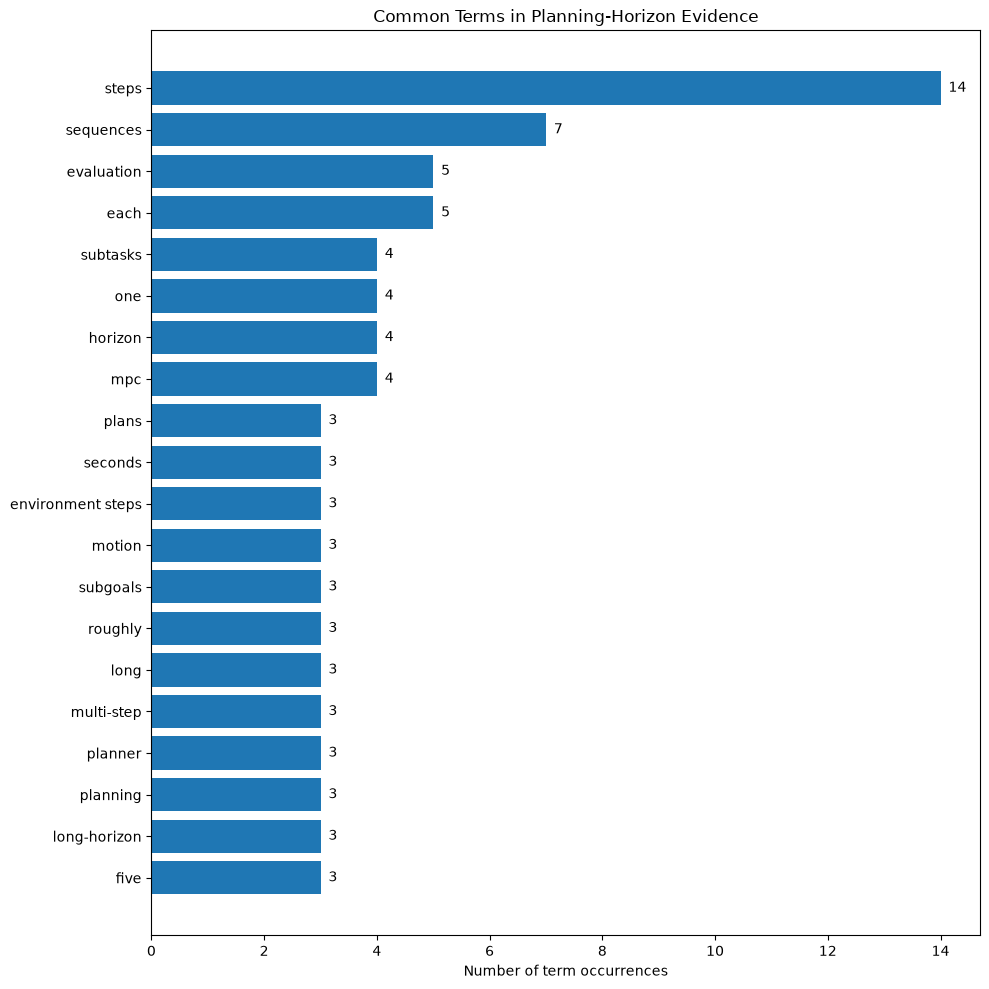

Saved: ../figs/analytical_plots/section_3_planning/common_terms_in_planning_horizon_evidence.png


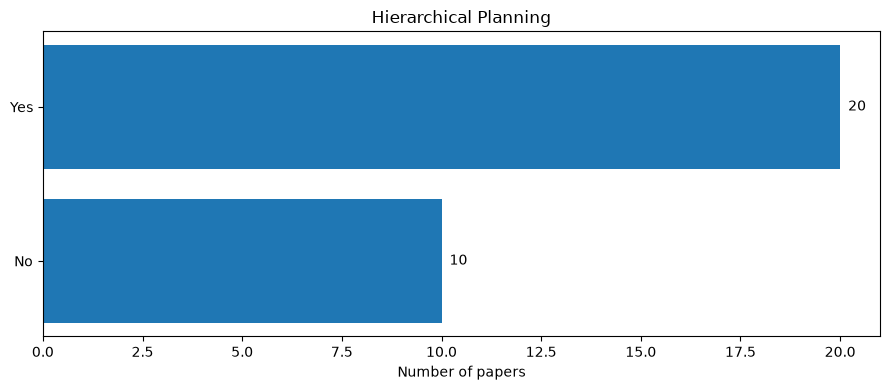

Saved: ../figs/analytical_plots/section_3_planning/hierarchical_planning.png


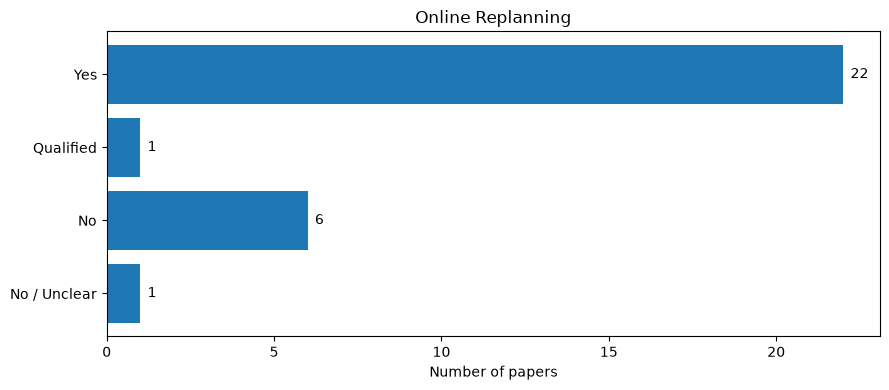

Saved: ../figs/analytical_plots/section_3_planning/online_replanning.png


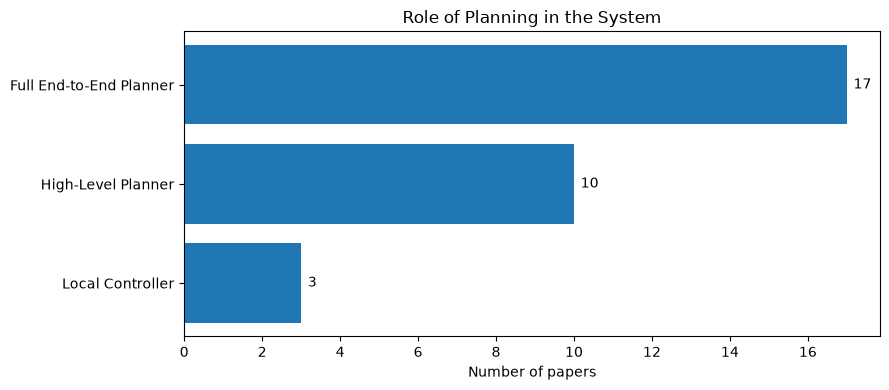

Saved: ../figs/analytical_plots/section_3_planning/role_of_planning_in_the_system.png


In [16]:
plot_multilabel_counts(
    planning_df,
    "planning_method",
    title="Planning Methods",
    section=SECTION,
    top_n=20,
)

plot_text_terms(
    planning_df,
    "planning_representation",
    title="Common Planning Representations",
    section=SECTION,
    top_n=20,
)

plot_category_counts(
    planning_df,
    "planning_horizon",
    title="Explicit Planning Horizon",
    section=SECTION,
    order=["Short", "Medium", "Long", "None", "N/A", "Missing"],
)

plot_text_terms(
    planning_df,
    "horizon_basis",
    title="Common Terms in Planning-Horizon Evidence",
    section=SECTION,
    top_n=20,
)

plot_category_counts(
    planning_df,
    "hierarchical_planning",
    title="Hierarchical Planning",
    section=SECTION,
    order=["Yes", "No", "No / Unclear", "N/A", "Missing"],
    transform=normalize_status,
)

plot_category_counts(
    planning_df,
    "replanning_online",
    title="Online Replanning",
    section=SECTION,
    order=[
        "Yes",
        "Qualified",
        "No",
        "No / Unclear",
        "N/A",
        "Missing",
    ],
    transform=normalize_status,
)

plot_category_counts(
    planning_df,
    "planning_role",
    title="Role of Planning in the System",
    section=SECTION,
)

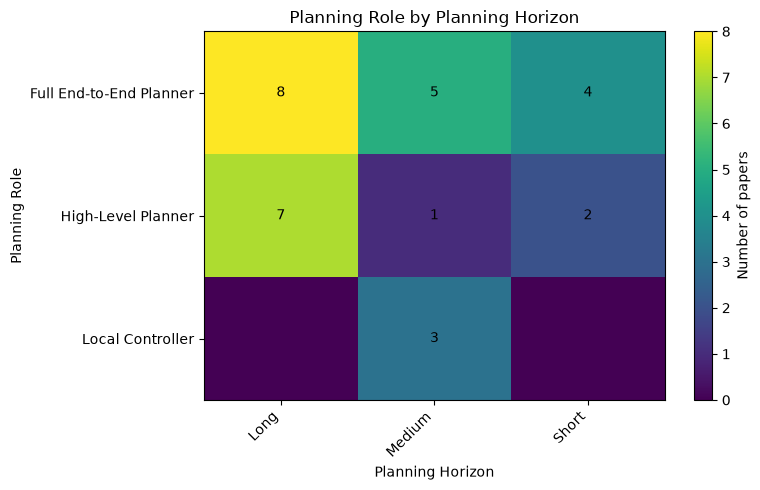

Saved: ../figs/analytical_plots/section_3_planning/planning_role_by_planning_horizon.png


In [17]:
plot_relationship_heatmap(
    planning_df,
    row_column="planning_role",
    column_column="planning_horizon",
    title="Planning Role by Planning Horizon",
    section=SECTION,
)

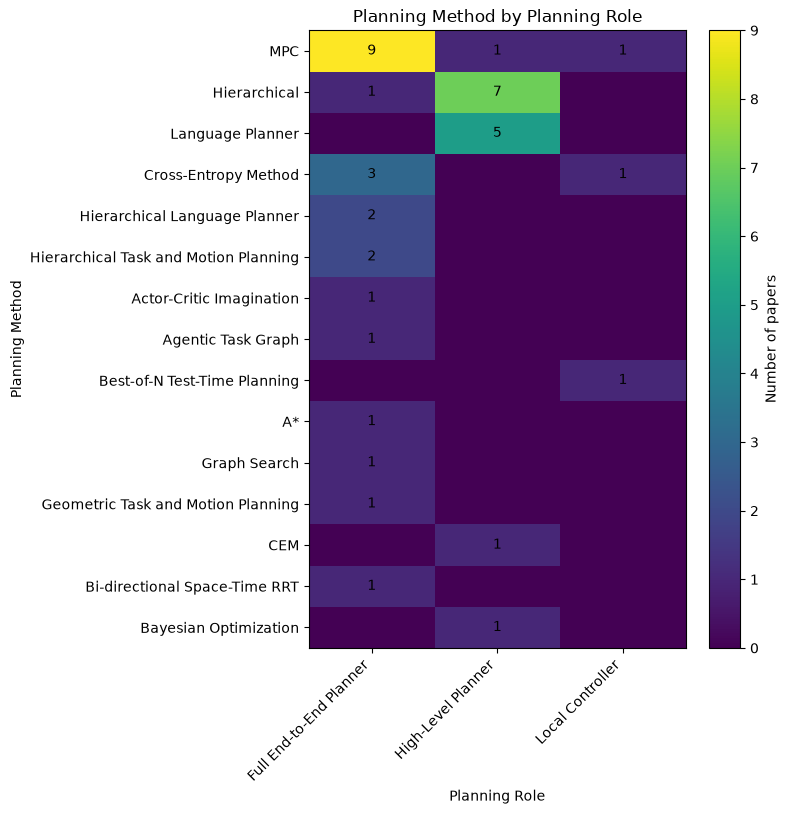

Saved: ../figs/analytical_plots/section_3_planning/planning_method_by_planning_role.png


In [18]:
plot_relationship_heatmap(
    planning_df,
    row_column="planning_method",
    column_column="planning_role",
    title="Planning Method by Planning Role",
    section=SECTION,
    row_multilabel=True,
    top_rows=15,
)

# Section 4: Inputs, goals, actions, learning

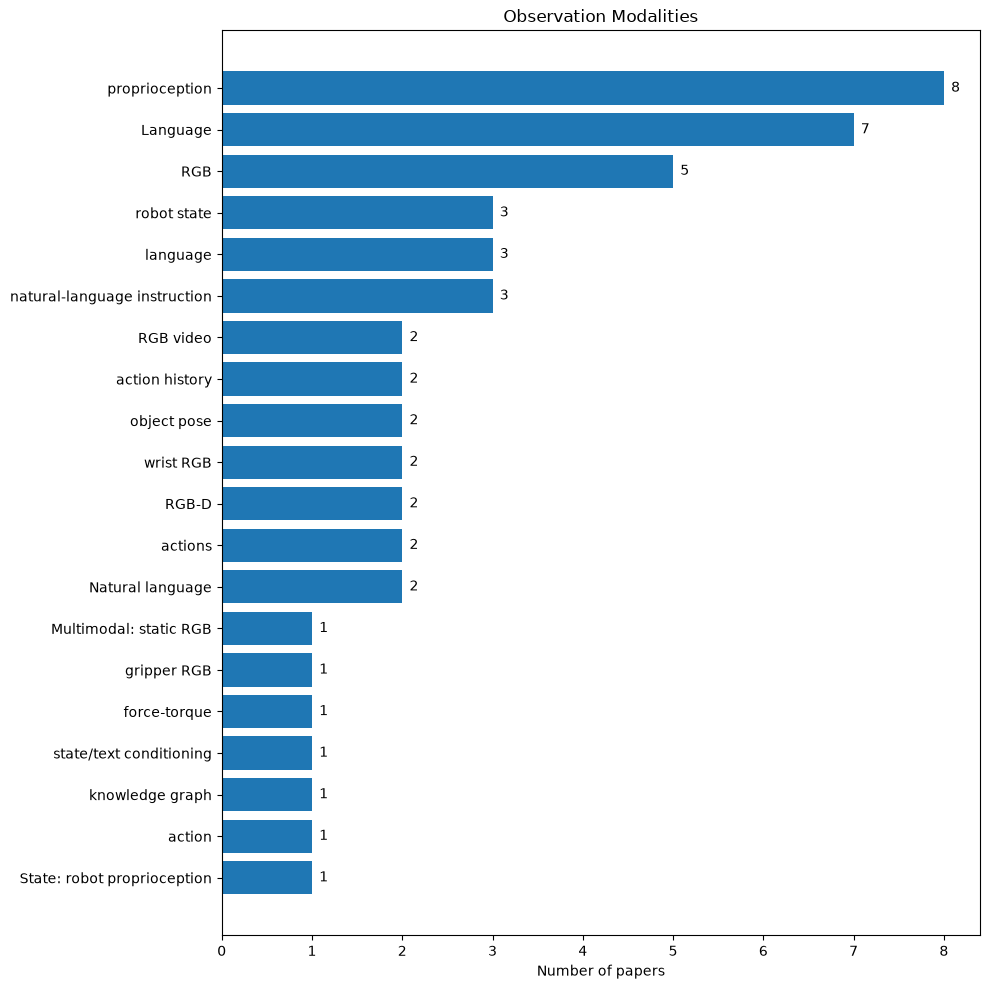

Saved: ../figs/analytical_plots/section_4_policy_and_representation/observation_modalities.png


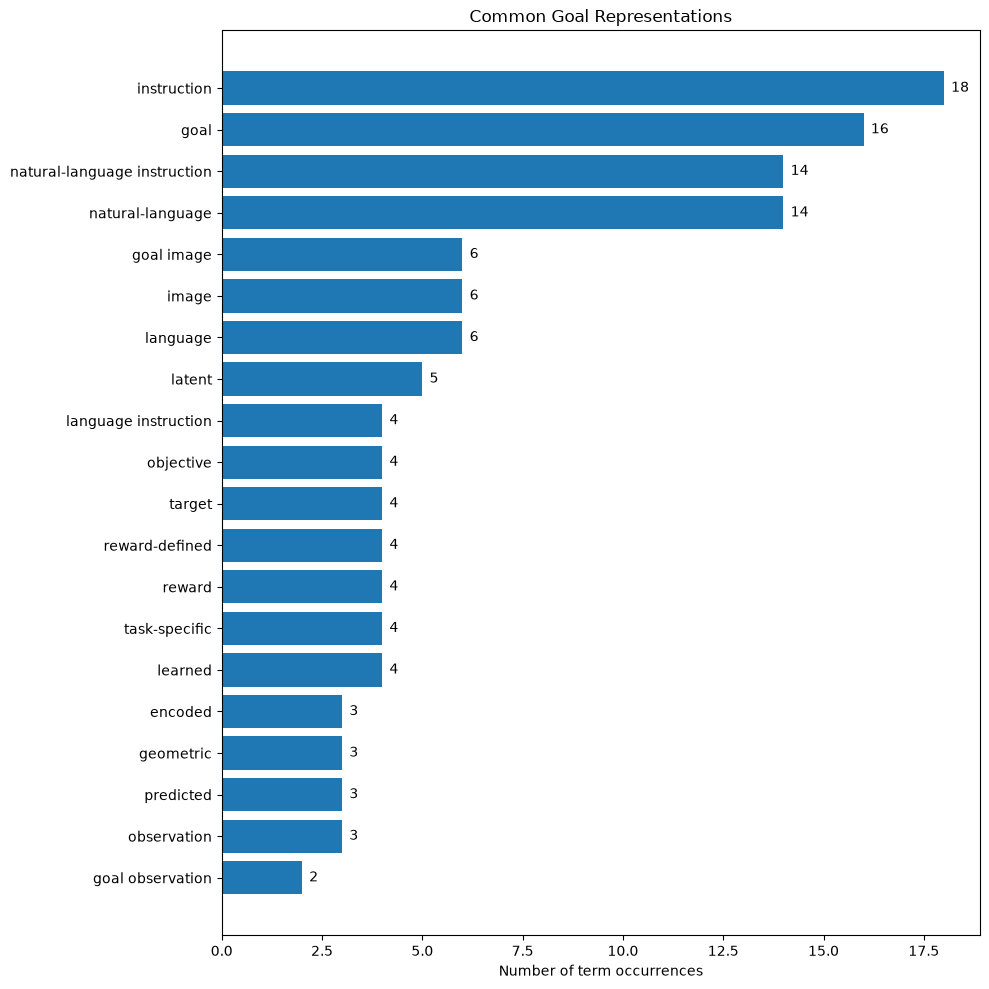

Saved: ../figs/analytical_plots/section_4_policy_and_representation/common_goal_representations.png


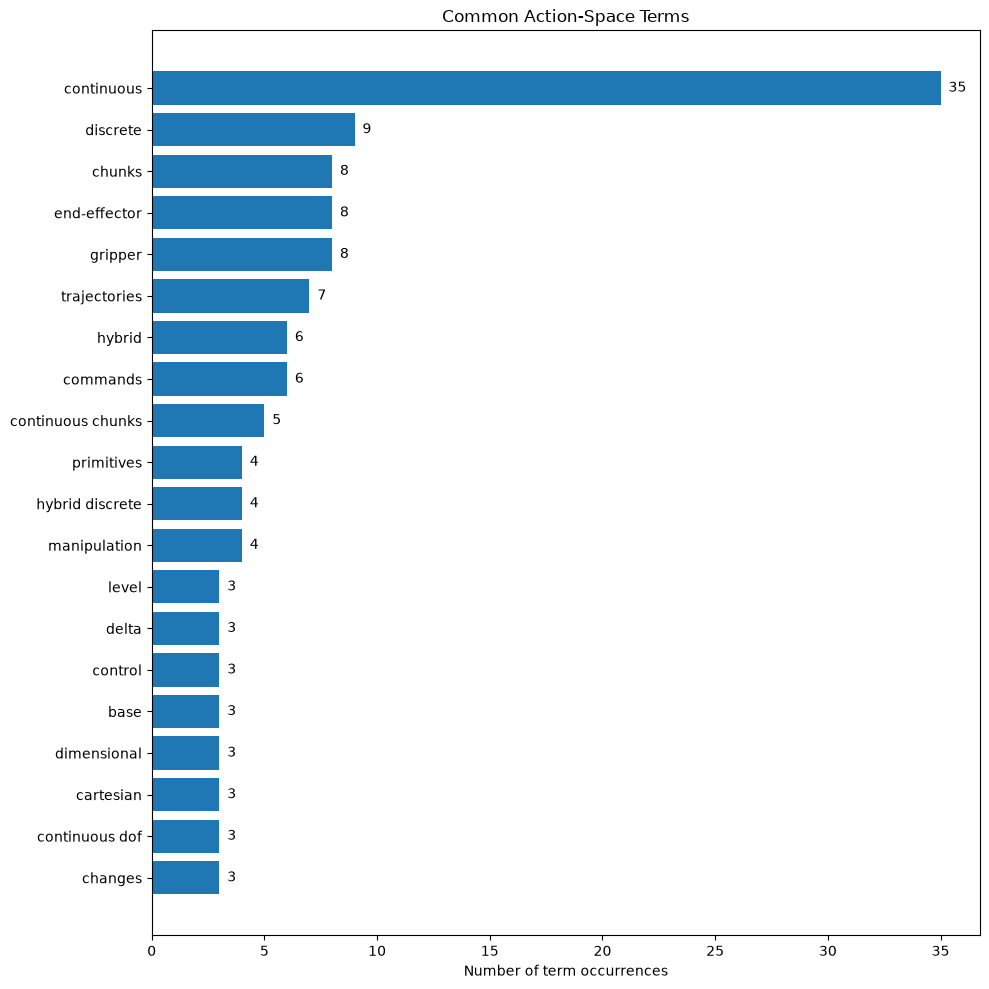

Saved: ../figs/analytical_plots/section_4_policy_and_representation/common_action_space_terms.png


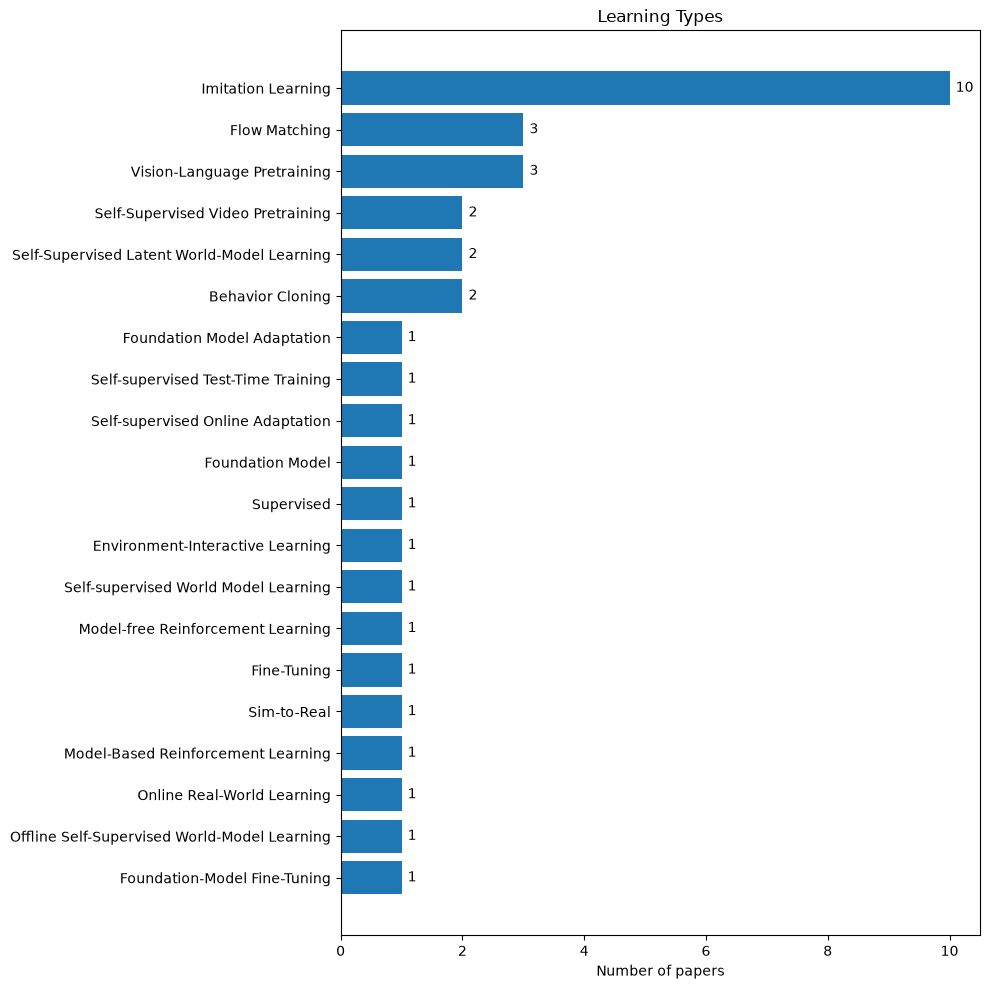

Saved: ../figs/analytical_plots/section_4_policy_and_representation/learning_types.png


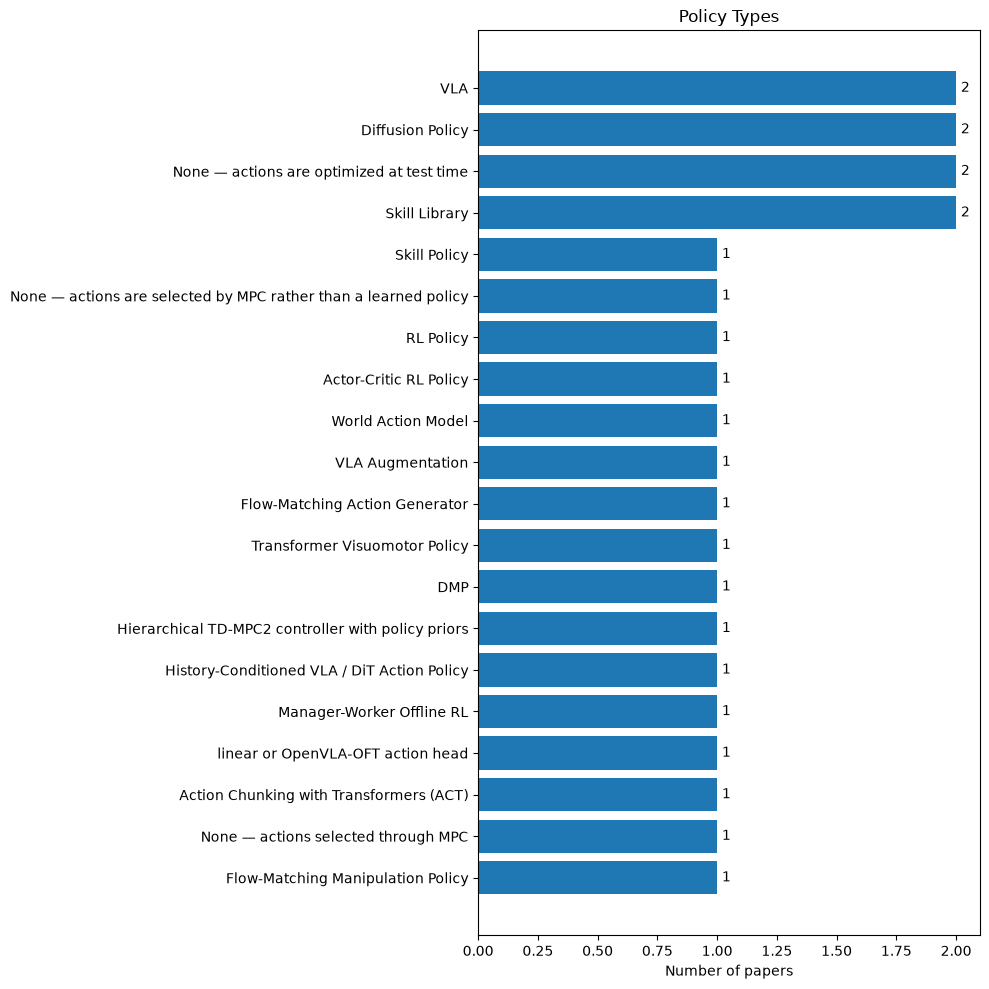

Saved: ../figs/analytical_plots/section_4_policy_and_representation/policy_types.png


In [19]:
SECTION = "section_4_policy_and_representation"

plot_multilabel_counts(
    analysis_df,
    "observation_modality",
    title="Observation Modalities",
    section=SECTION,
    top_n=20,
)

plot_text_terms(
    analysis_df,
    "goal_representation",
    title="Common Goal Representations",
    section=SECTION,
    top_n=20,
)

plot_text_terms(
    analysis_df,
    "action_space",
    title="Common Action-Space Terms",
    section=SECTION,
    top_n=20,
)

plot_multilabel_counts(
    analysis_df,
    "learning_type",
    title="Learning Types",
    section=SECTION,
    top_n=20,
)

plot_multilabel_counts(
    analysis_df,
    "policy_type",
    title="Policy Types",
    section=SECTION,
    top_n=20,
)

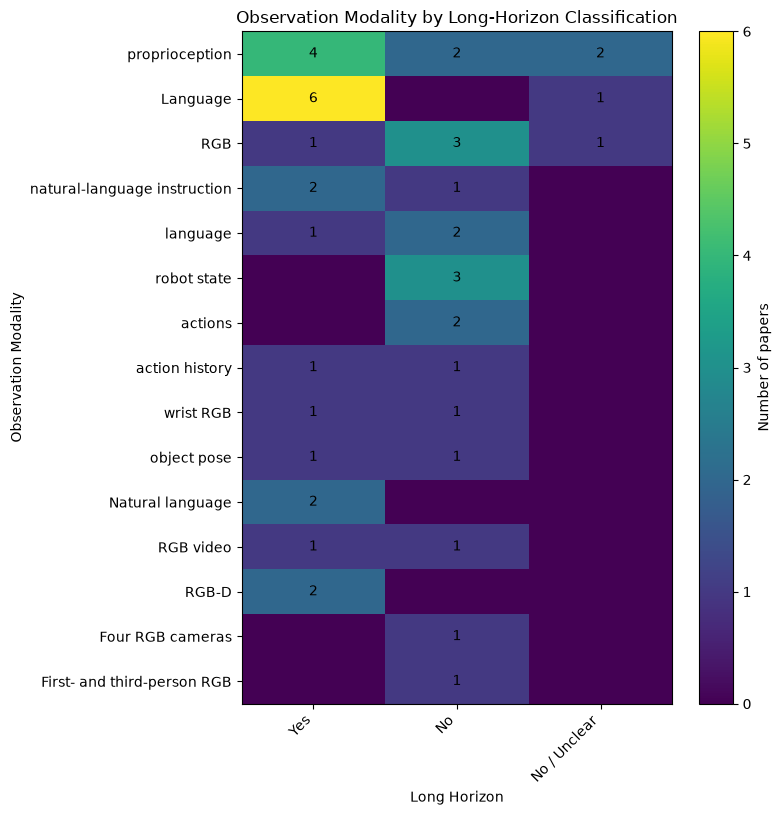

Saved: ../figs/analytical_plots/section_4_policy_and_representation/observation_modality_by_long_horizon_classification.png


In [20]:
plot_relationship_heatmap(
    analysis_df,
    row_column="observation_modality",
    column_column="long_horizon",
    title="Observation Modality by Long-Horizon Classification",
    section=SECTION,
    row_multilabel=True,
    column_transform=normalize_status,
    top_rows=15,
)

# Section 5: Evaluation and deployment

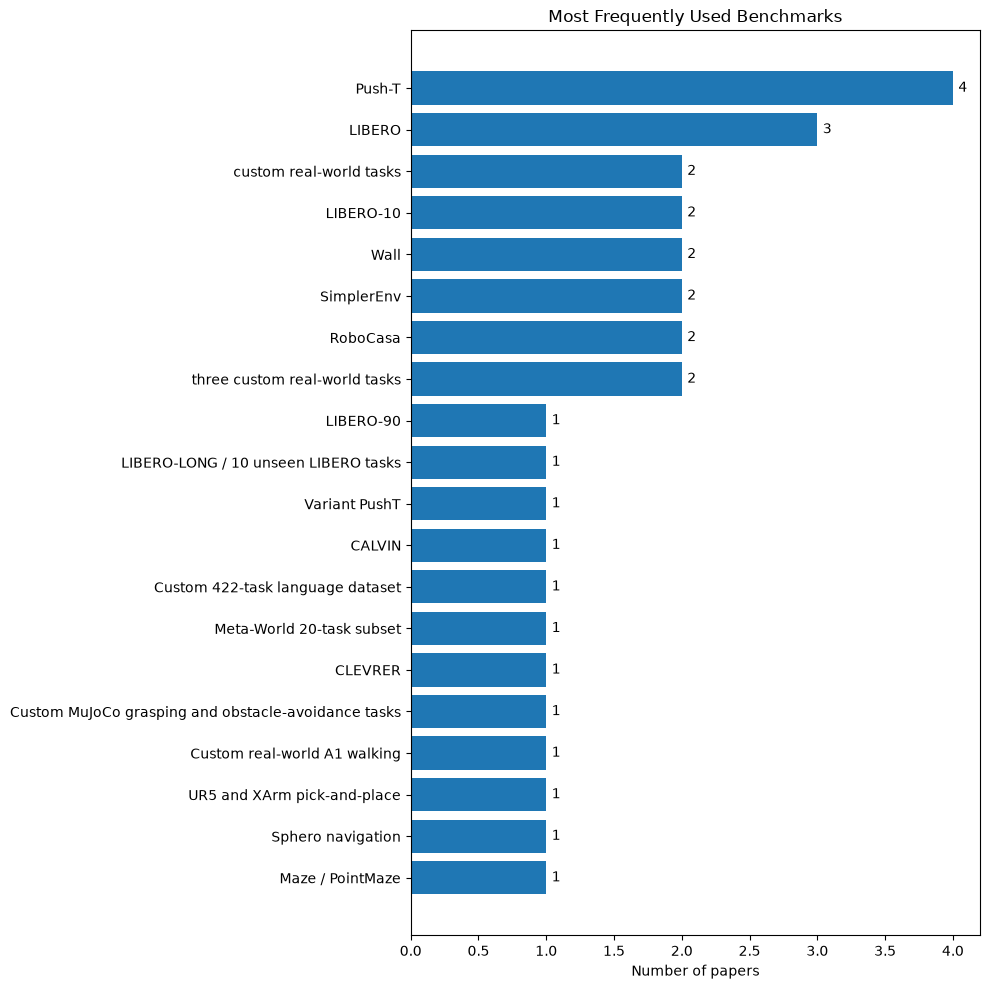

Saved: ../figs/analytical_plots/section_5_evaluation_and_deployment/most_frequently_used_benchmarks.png


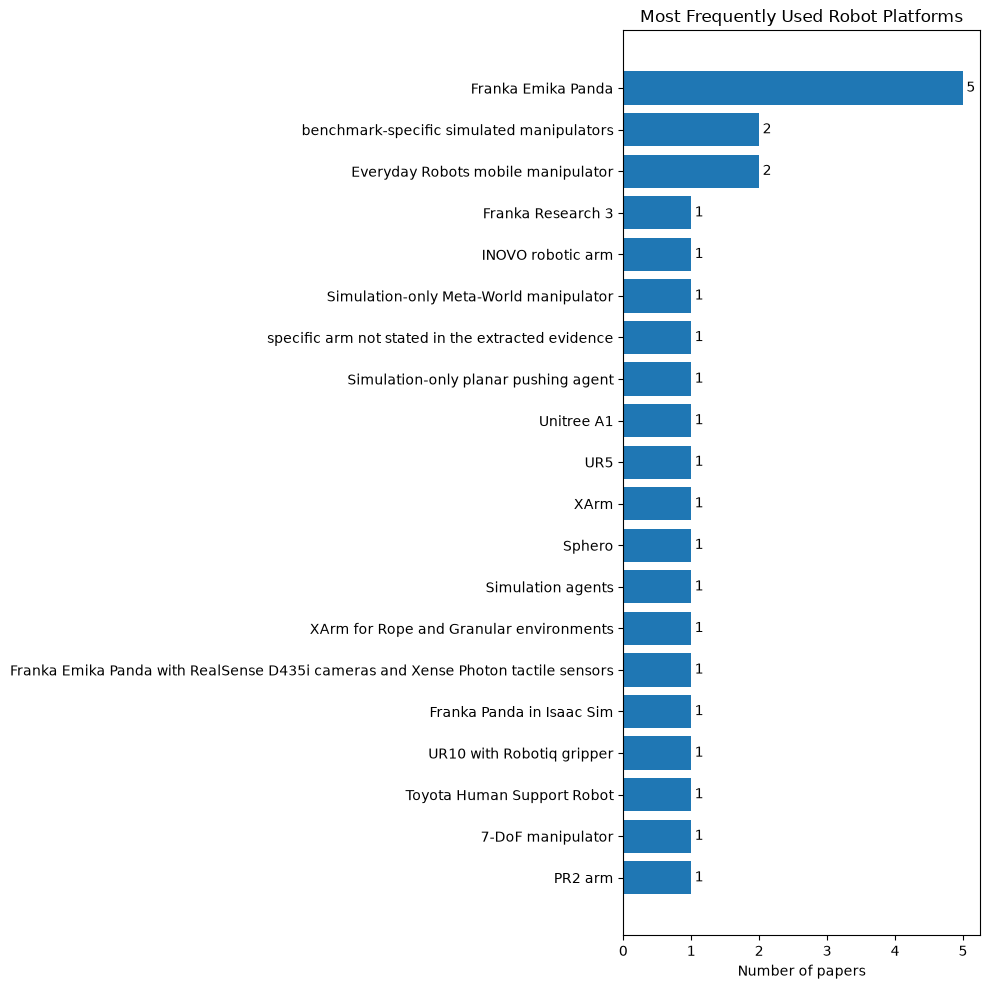

Saved: ../figs/analytical_plots/section_5_evaluation_and_deployment/most_frequently_used_robot_platforms.png


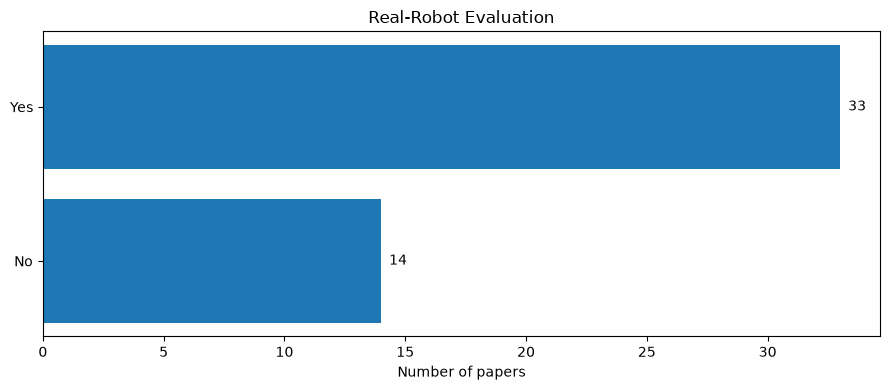

Saved: ../figs/analytical_plots/section_5_evaluation_and_deployment/real_robot_evaluation.png


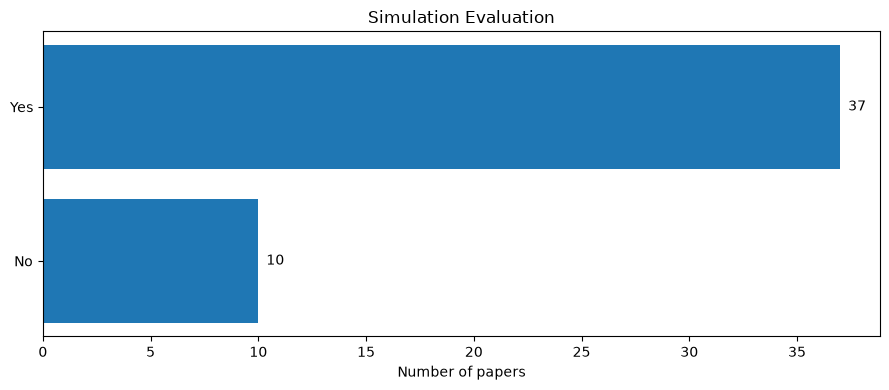

Saved: ../figs/analytical_plots/section_5_evaluation_and_deployment/simulation_evaluation.png


In [21]:
SECTION = "section_5_evaluation_and_deployment"

plot_multilabel_counts(
    analysis_df,
    "benchmark",
    title="Most Frequently Used Benchmarks",
    section=SECTION,
    top_n=20,
)

plot_multilabel_counts(
    analysis_df,
    "robot_platform",
    title="Most Frequently Used Robot Platforms",
    section=SECTION,
    top_n=20,
)

plot_category_counts(
    analysis_df,
    "real_robot",
    title="Real-Robot Evaluation",
    section=SECTION,
    order=[
        "Yes",
        "No",
        "Both / Survey",
        "No / Unclear",
        "N/A",
        "Missing",
    ],
    transform=normalize_status,
)

plot_category_counts(
    analysis_df,
    "simulation",
    title="Simulation Evaluation",
    section=SECTION,
    order=[
        "Yes",
        "No",
        "Both / Survey",
        "No / Unclear",
        "N/A",
        "Missing",
    ],
    transform=normalize_status,
)

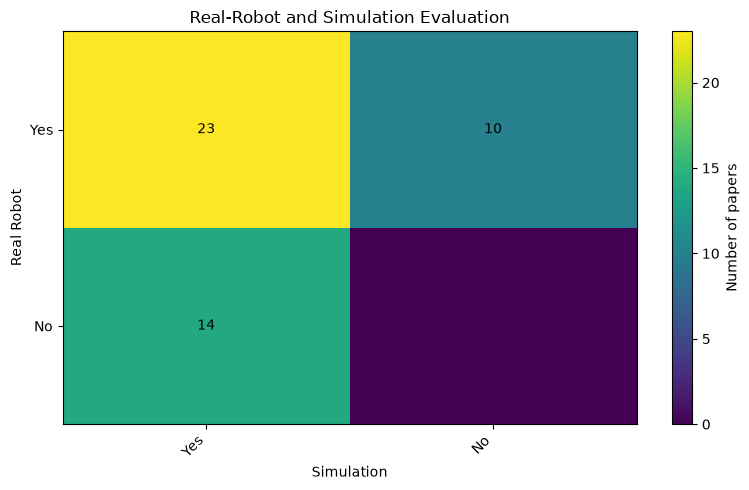

Saved: ../figs/analytical_plots/section_5_evaluation_and_deployment/real_robot_and_simulation_evaluation.png


In [22]:
plot_relationship_heatmap(
    analysis_df,
    row_column="real_robot",
    column_column="simulation",
    title="Real-Robot and Simulation Evaluation",
    section=SECTION,
    row_transform=normalize_status,
    column_transform=normalize_status,
)

# Numerical Overview

## Metric Definitions

The percentages below use the **47 method papers** as the denominator. These categories are not mutually exclusive, so a single paper may be counted under several metrics.

| Metric                            | Meaning in this dataset                                                                                                                                                                                                                                                                                                                                                                               |
| --------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **World-model methods**           | Methods containing a learned model that predicts how the environment evolves. Predictions may be future images, latent states, object states, rewards, or other task-relevant states. Direct action-only policies, frozen visual encoders used only for representation, ordinary history-conditioned policies, knowledge graphs without learned transitions, and analytical simulators were excluded. |
| **Explicit-planning methods**     | Methods that explicitly search for, optimize, select, or structurally construct behavior. Examples include MPC, CEM, MCTS, A*, Bayesian optimization, task-and-motion planning, symbolic planning, and learned high-level subgoal planning. Direct policies that simply output an action or action chunk were not counted.                                                                            |
| **Long-horizon methods**          | Methods evaluated on temporally extended tasks involving multiple stages, subgoals, skills, or prolonged interaction. This refers to the **task horizon**, not necessarily the numerical prediction or planning horizon.                                                                                                                                                                              |
| **Language-conditioned methods**  | Methods where natural language is an actual input used to specify the task, goal, subtask, reward, plan, or desired behavior. Papers that only discuss language without conditioning the method were not counted.                                                                                                                                                                                     |
| **Hierarchical-planning methods** | Methods containing at least two distinct planning or control levels, such as an LLM task planner above a skill controller, a symbolic planner above motion planning, or a latent high-level planner above a low-level policy. A neural network with multiple layers or modules was not sufficient by itself.                                                                                          |
| **Online-replanning methods**     | Methods that update their plan, subgoal, action sequence, or action chunk using new observations during execution. This includes explicit receding-horizon planners and direct closed-loop policies that regenerate actions from feedback.                                                                                                                                                            |
| **Real-robot methods**            | Methods evaluated or deployed on physical robot hardware. Training only on previously collected real-robot data was not normally counted unless the proposed method was physically executed or evaluated.                                                                                                                                                                                             |
| **Simulation methods**            | Methods evaluated in a simulator or simulated benchmark, including physics-based manipulation, navigation, or control environments. Papers evaluated in both simulation and the real world are counted in both categories.                                                                                                                                                                            |


## Important Classification Distinctions

* **World model vs. planner:** A method may predict future states without using those predictions to search for or optimize actions. Therefore, not every world-model method is an explicit-planning method.

* **Long horizon vs. planning horizon:** A method can solve a long, multi-stage task while only predicting or planning a short action chunk at each step. `long_horizon` describes the task, while `planning_horizon` describes how far the planner explicitly reasons ahead.

* **Hierarchical architecture vs. hierarchical planning:** A system containing several neural modules is not automatically hierarchical planning. The method must contain distinct decision-making levels, such as task planning, skill selection, and low-level control.

* **Online replanning vs. explicit planning:** Online replanning is broader than search-based planning. A direct policy that regenerates action chunks from new observations may count as online replanning even when `uses_planning = No`.

* **Real-robot data vs. real-robot evaluation:** Using a dataset collected from physical robots does not necessarily mean the proposed method was evaluated on hardware. `real_robot = Yes` generally requires physical execution or deployment of the method.

* **Simulation and real-robot evaluation:** These categories overlap. A paper tested in both simulation and on physical hardware is included in both counts.


In [23]:
summary = pd.DataFrame(
    {
        "Metric": [
            "Papers analyzed",
            "World-model methods",
            "Explicit-planning methods",
            "Long-horizon methods",
            "Language-conditioned methods",
            "Hierarchical-planning methods",
            "Online-replanning methods",
            "Real-robot methods",
            "Simulation methods",
        ],
        "Count": [
            len(analysis_df),

            analysis_df["uses_world_model"]
            .eq("Yes")
            .sum(),

            analysis_df["uses_planning"]
            .eq("Yes")
            .sum(),

            analysis_df["long_horizon"]
            .map(normalize_status)
            .eq("Yes")
            .sum(),

            analysis_df["language_conditioned"]
            .map(normalize_status)
            .eq("Yes")
            .sum(),

            analysis_df["hierarchical_planning"]
            .map(normalize_status)
            .eq("Yes")
            .sum(),

            analysis_df["replanning_online"]
            .map(normalize_status)
            .eq("Yes")
            .sum(),

            analysis_df["real_robot"]
            .map(normalize_status)
            .eq("Yes")
            .sum(),

            analysis_df["simulation"]
            .map(normalize_status)
            .eq("Yes")
            .sum(),
        ],
    }
)

summary["Percentage"] = (
    100 * summary["Count"] / len(analysis_df)
).round(1)

summary

,Metric,Count,Percentage
0,Papers analyzed,47,100.0
1,World-model methods,26,55.3
2,Explicit-planning methods,30,63.8
3,Long-horizon methods,24,51.1
4,Language-conditioned methods,24,51.1
5,Hierarchical-planning methods,20,42.6
6,Online-replanning methods,36,76.6
7,Real-robot methods,33,70.2
8,Simulation methods,37,78.7
